# Project

MLF_GP2_EconCycle

### Part 1: EDA

In [3]:
# libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LassoCV, RidgeCV, ElasticNetCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor, VotingRegressor, StackingRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline

In [4]:
# read data
df = pd.read_csv('../data/MLF_GP2_EconCycle.csv')

df['Date'] = pd.to_datetime(df['Date'])

In [5]:
# Shape
print("Dataset shape:", df.shape)
print("\nFirst look at the data:")
print(df.head())

Dataset shape: (223, 17)

First look at the data:
        Date  T1Y Index  T2Y Index  T3Y Index  T5Y Index  T7Y Index  \
0 1979-01-31      10.41       9.86       9.50       9.20       9.14   
1 1979-02-28      10.24       9.72       9.29       9.13       9.11   
2 1979-03-31      10.25       9.79       9.38       9.20       9.15   
3 1979-04-30      10.12       9.78       9.43       9.25       9.21   
4 1979-05-31      10.12       9.78       9.42       9.24       9.23   

   T10Y Index  CP1M  CP3M   CP6M  CP1M_T1Y  CP3M_T1Y  CP6M_T1Y  USPHCI  \
0        9.10  9.75  9.95  10.01  0.936599  0.955812  0.961575   47.08   
1        9.10  9.74  9.90   9.96  0.951172  0.966797  0.972656   47.32   
2        9.12  9.72  9.85   9.87  0.948293  0.960976  0.962927   47.39   
3        9.18  9.86  9.95   9.98  0.974308  0.983202  0.986166   47.62   
4        9.25  9.77  9.76   9.71  0.965415  0.964427  0.959486   47.76   

   PCT 3MO FWD  PCT 6MO FWD  PCT 9MO FWD  
0     0.011470     0.018060     0.0

In [6]:
# Data types
print("Data types:")
print(df.dtypes)
print(f"\nTotal columns: {len(df.columns)}")

Data types:
Date           datetime64[ns]
T1Y Index             float64
T2Y Index             float64
T3Y Index             float64
T5Y Index             float64
T7Y Index             float64
T10Y Index            float64
CP1M                  float64
CP3M                  float64
CP6M                  float64
CP1M_T1Y              float64
CP3M_T1Y              float64
CP6M_T1Y              float64
USPHCI                float64
PCT 3MO FWD           float64
PCT 6MO FWD           float64
PCT 9MO FWD           float64
dtype: object

Total columns: 17


In [7]:
# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Date           0
T1Y Index      0
T2Y Index      0
T3Y Index      0
T5Y Index      0
T7Y Index      0
T10Y Index     0
CP1M           0
CP3M           0
CP6M           0
CP1M_T1Y       0
CP3M_T1Y       0
CP6M_T1Y       0
USPHCI         0
PCT 3MO FWD    0
PCT 6MO FWD    0
PCT 9MO FWD    0
dtype: int64


In [8]:
# Basic statistics
print("\nDescriptive Statistics:")
print(df.describe())


Descriptive Statistics:
                                Date   T1Y Index   T2Y Index   T3Y Index  \
count                            223  223.000000  223.000000  223.000000   
mean   1988-04-30 10:06:59.730941696    8.030717    8.410673    8.563587   
min              1979-01-31 00:00:00    3.180000    3.840000    4.170000   
25%              1983-09-15 00:00:00    5.735000    6.180000    6.410000   
50%              1988-04-30 00:00:00    7.670000    8.000000    8.130000   
75%              1992-12-15 12:00:00    9.840000   10.075000   10.375000   
max              1997-07-31 00:00:00   16.720000   16.460000   16.220000   
std                              NaN    3.158575    2.954431    2.820405   

        T5Y Index   T7Y Index  T10Y Index        CP1M        CP3M        CP6M  \
count  223.000000  223.000000  223.000000  223.000000  223.000000  223.000000   
mean     8.808655    8.979776    9.073498    7.942197    7.936906    7.892780   
min      4.710000    5.050000    5.330000    3.

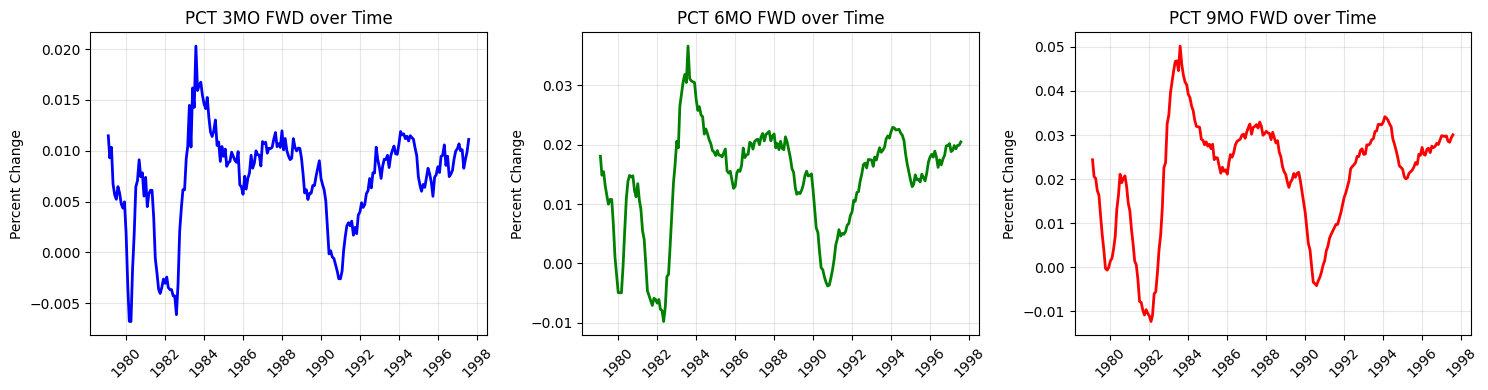

In [9]:
# Plot target variables over time
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

targets = ['PCT 3MO FWD', 'PCT 6MO FWD', 'PCT 9MO FWD']
colors = ['blue', 'green', 'red']

for i, target in enumerate(targets):
    axes[i].plot(df['Date'], df[target], color=colors[i], linewidth=2)
    axes[i].set_title(f'{target} over Time')
    axes[i].set_ylabel('Percent Change')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

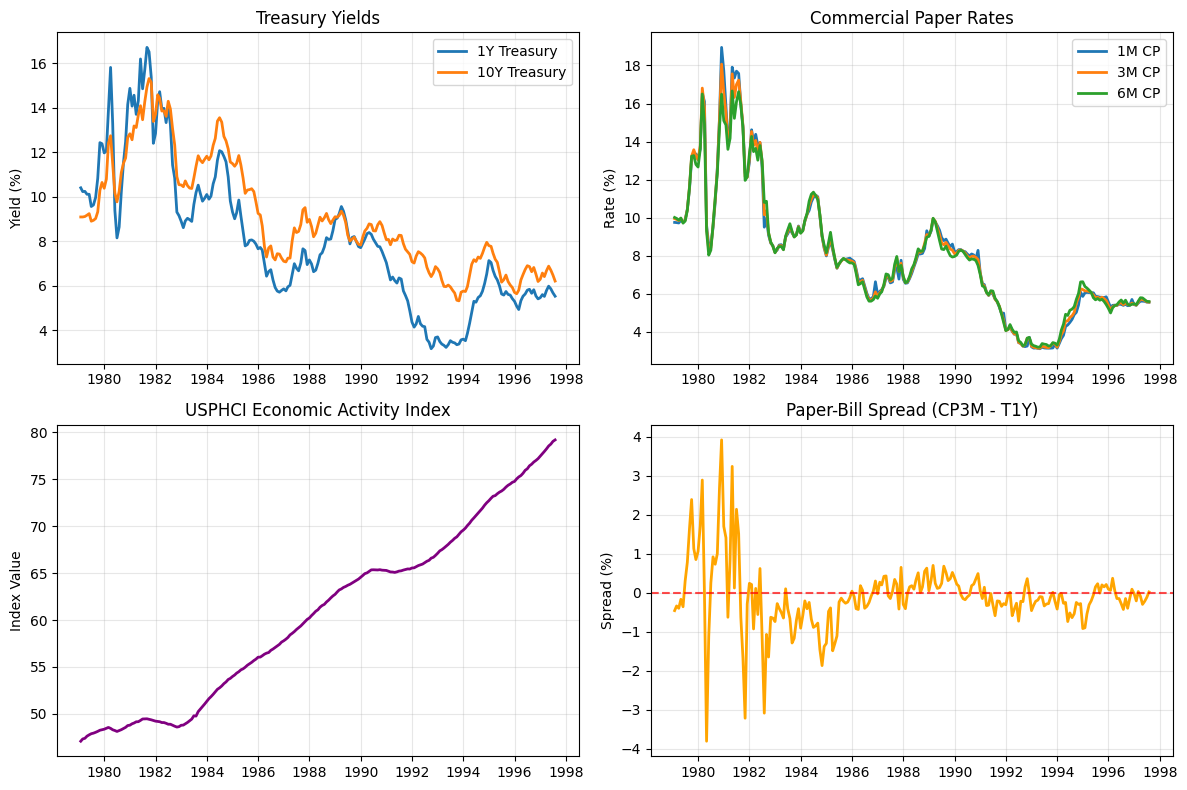

In [10]:
# Plot some key interest rates
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Treasury yields
axes[0,0].plot(df['Date'], df['T1Y Index'], label='1Y Treasury', linewidth=2)
axes[0,0].plot(df['Date'], df['T10Y Index'], label='10Y Treasury', linewidth=2)
axes[0,0].set_title('Treasury Yields')
axes[0,0].set_ylabel('Yield (%)')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Commercial paper rates
axes[0,1].plot(df['Date'], df['CP1M'], label='1M CP', linewidth=2)
axes[0,1].plot(df['Date'], df['CP3M'], label='3M CP', linewidth=2)
axes[0,1].plot(df['Date'], df['CP6M'], label='6M CP', linewidth=2)
axes[0,1].set_title('Commercial Paper Rates')
axes[0,1].set_ylabel('Rate (%)')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# USPHCI index
axes[1,0].plot(df['Date'], df['USPHCI'], color='purple', linewidth=2)
axes[1,0].set_title('USPHCI Economic Activity Index')
axes[1,0].set_ylabel('Index Value')
axes[1,0].grid(True, alpha=0.3)

# Paper-Bill spread (key feature from Friedman & Kuttner)
df['Paper_Bill_Spread'] = df['CP3M'] - df['T1Y Index']
axes[1,1].plot(df['Date'], df['Paper_Bill_Spread'], color='orange', linewidth=2)
axes[1,1].set_title('Paper-Bill Spread (CP3M - T1Y)')
axes[1,1].set_ylabel('Spread (%)')
axes[1,1].axhline(y=0, color='red', linestyle='--', alpha=0.7)
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

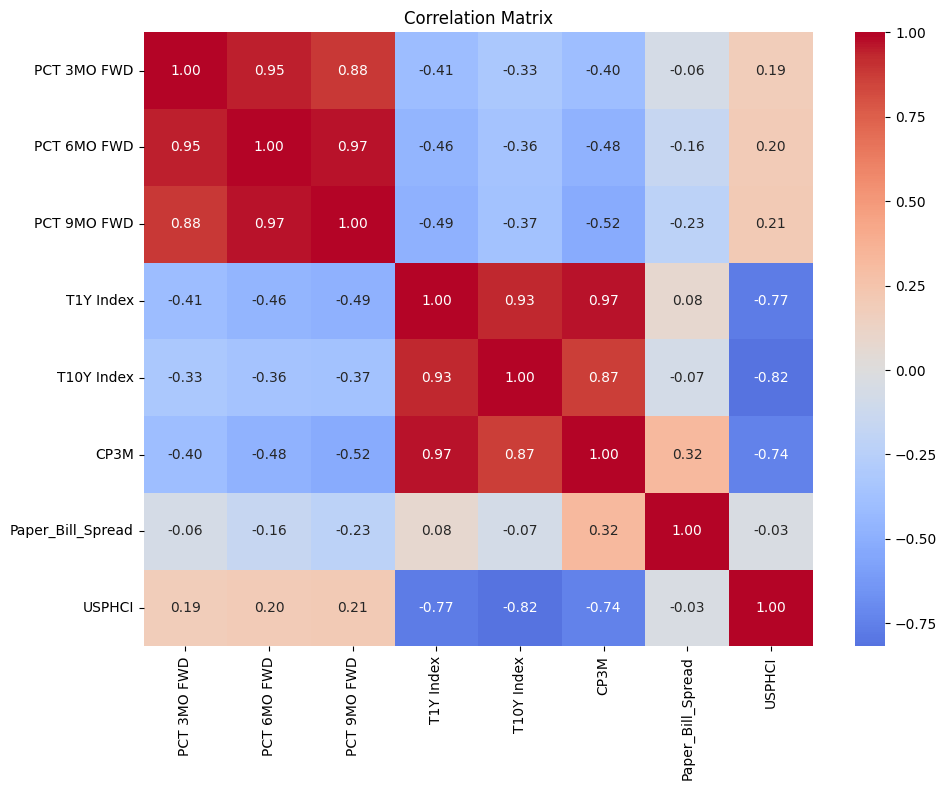

In [11]:
# Correlation heatmap for targets
target_corr = df[['PCT 3MO FWD', 'PCT 6MO FWD', 'PCT 9MO FWD',
                  'T1Y Index', 'T10Y Index', 'CP3M', 'Paper_Bill_Spread', 'USPHCI']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(target_corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

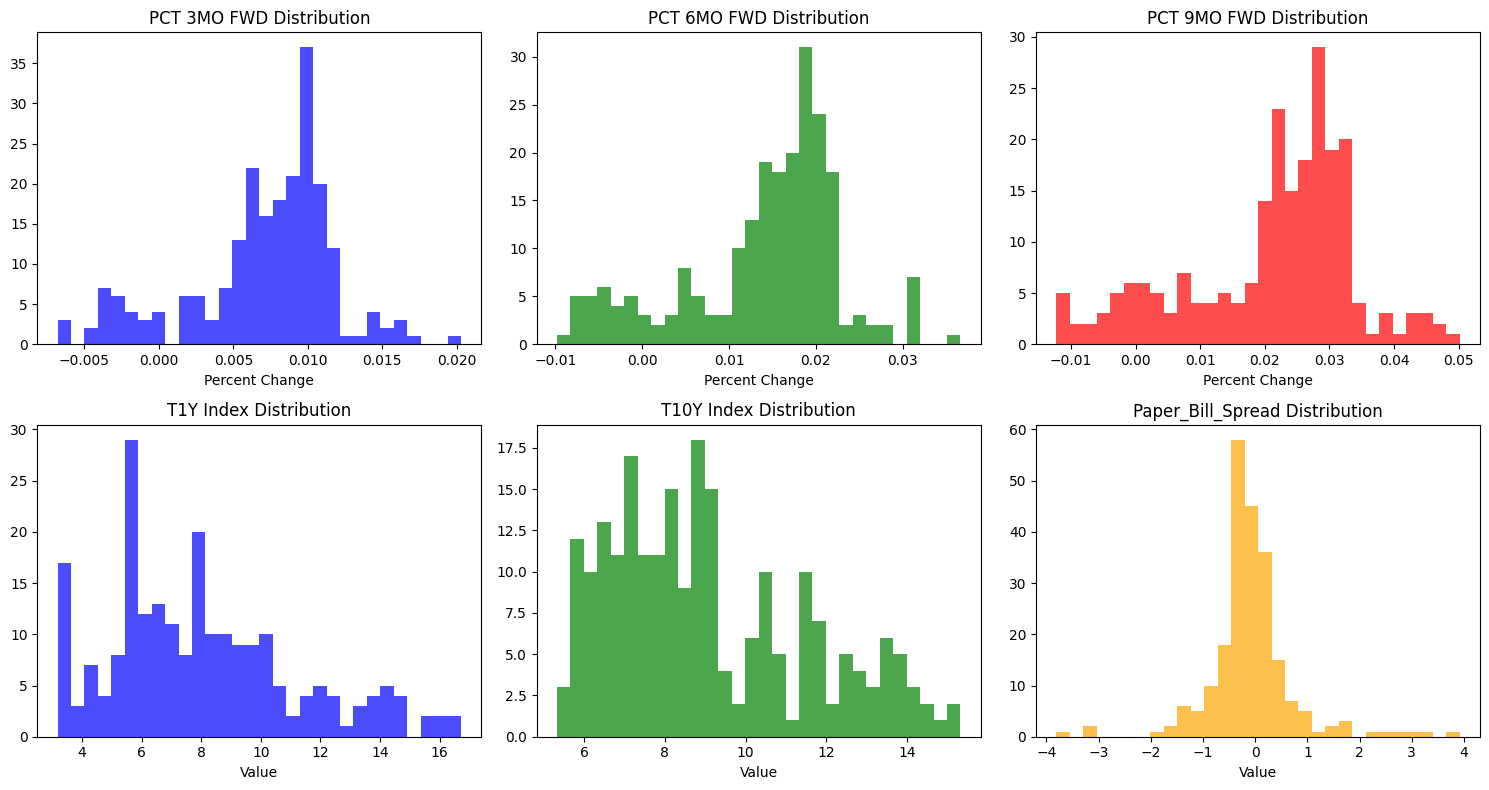

In [12]:
# Distribution plots
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Target distributions
for i, target in enumerate(targets):
    axes[0,i].hist(df[target], bins=30, alpha=0.7, color=colors[i])
    axes[0,i].set_title(f'{target} Distribution')
    axes[0,i].set_xlabel('Percent Change')

# Key feature distributions
key_features = ['T1Y Index', 'T10Y Index', 'Paper_Bill_Spread']
key_colors = ['blue', 'green', 'orange']

for i, feature in enumerate(key_features):
    axes[1,i].hist(df[feature], bins=30, alpha=0.7, color=key_colors[i])
    axes[1,i].set_title(f'{feature} Distribution')
    axes[1,i].set_xlabel('Value')

plt.tight_layout()
plt.show()

- Yield curve slope: Difference between 10-year and 1-year Treasury yields. This is a key macroeconomic indicator - positive slope suggests economic expansion, inverted slope (negative) often predicts recessions.
- Various spreads: Difference between Commercial Paper rates and Treasury rates. These are the "Paper-Bill spreads" from the Friedman & Kuttner paper Wider spreads indicate higher perceived risk in corporate borrowing vs government debt.

In [13]:
# Create some basic engineered features
# Yield curve slope
df['Yield_Curve_Slope'] = df['T10Y Index'] - df['T1Y Index']

# Various spreads
# This often predicts changes in economic activity
df['CP_T1Y_Spread_3M'] = df['CP3M'] - df['T1Y Index']  # 3-month commercial paper vs 1-year Treasury
df['CP_T1Y_Spread_6M'] = df['CP6M'] - df['T1Y Index']  # 6-month commercial paper vs 1-year Treasury

print("Engineered features created:")
print(f"- Yield Curve Slope: {df['Yield_Curve_Slope'].mean():.3f} (mean)")  # Show average slope value
print(f"- CP-T1Y Spread 3M: {df['CP_T1Y_Spread_3M'].mean():.3f} (mean)")  # Show average 3M spread
print(f"- CP-T1Y Spread 6M: {df['CP_T1Y_Spread_6M'].mean():.3f} (mean)")  # Show average 6M spread

Engineered features created:
- Yield Curve Slope: 1.043 (mean)
- CP-T1Y Spread 3M: -0.094 (mean)
- CP-T1Y Spread 6M: -0.138 (mean)


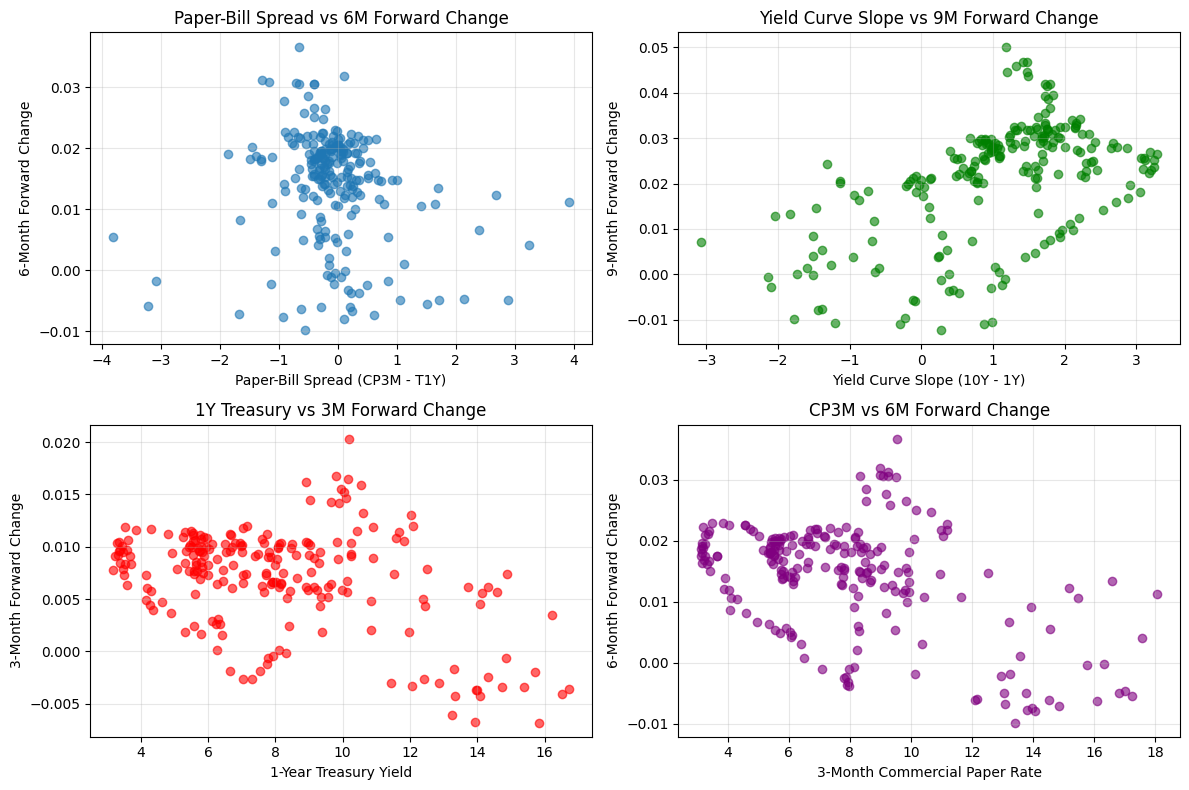

In [14]:
# Plot engineered features vs targets
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Paper-Bill spread vs 6-month forward change
axes[0,0].scatter(df['Paper_Bill_Spread'], df['PCT 6MO FWD'], alpha=0.6)
axes[0,0].set_xlabel('Paper-Bill Spread (CP3M - T1Y)')
axes[0,0].set_ylabel('6-Month Forward Change')
axes[0,0].set_title('Paper-Bill Spread vs 6M Forward Change')
axes[0,0].grid(True, alpha=0.3)

# Yield curve slope vs 9-month forward change
axes[0,1].scatter(df['Yield_Curve_Slope'], df['PCT 9MO FWD'], alpha=0.6, color='green')
axes[0,1].set_xlabel('Yield Curve Slope (10Y - 1Y)')
axes[0,1].set_ylabel('9-Month Forward Change')
axes[0,1].set_title('Yield Curve Slope vs 9M Forward Change')
axes[0,1].grid(True, alpha=0.3)

# 1Y Treasury vs 3-month forward change
axes[1,0].scatter(df['T1Y Index'], df['PCT 3MO FWD'], alpha=0.6, color='red')
axes[1,0].set_xlabel('1-Year Treasury Yield')
axes[1,0].set_ylabel('3-Month Forward Change')
axes[1,0].set_title('1Y Treasury vs 3M Forward Change')
axes[1,0].grid(True, alpha=0.3)

# Commercial Paper 3M vs 6-month forward change
axes[1,1].scatter(df['CP3M'], df['PCT 6MO FWD'], alpha=0.6, color='purple')
axes[1,1].set_xlabel('3-Month Commercial Paper Rate')
axes[1,1].set_ylabel('6-Month Forward Change')
axes[1,1].set_title('CP3M vs 6M Forward Change')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
# Prepare features for modeling (exclude Date and USPHCI)
feature_columns = [col for col in df.columns if col not in ['Date', 'USPHCI', 'PCT 3MO FWD', 'PCT 6MO FWD', 'PCT 9MO FWD']]
print(f"Number of features: {len(feature_columns)}")
print("\nFeatures to use:")
print(feature_columns)

Number of features: 16

Features to use:
['T1Y Index', 'T2Y Index', 'T3Y Index', 'T5Y Index', 'T7Y Index', 'T10Y Index', 'CP1M', 'CP3M', 'CP6M', 'CP1M_T1Y', 'CP3M_T1Y', 'CP6M_T1Y', 'Paper_Bill_Spread', 'Yield_Curve_Slope', 'CP_T1Y_Spread_3M', 'CP_T1Y_Spread_6M']


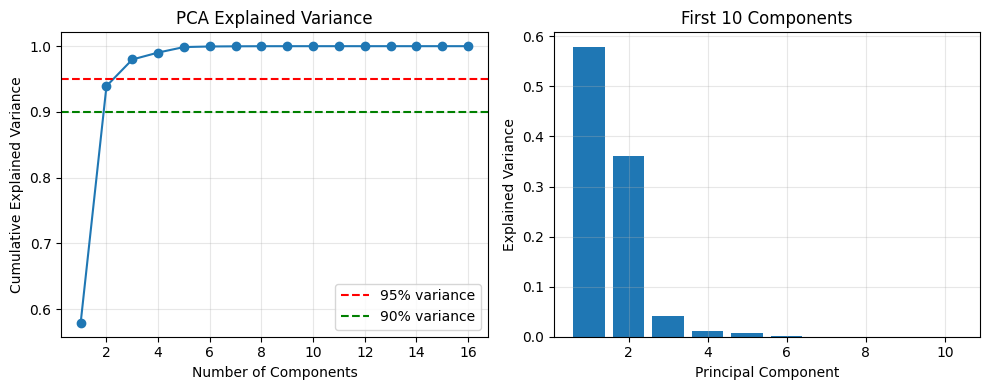

Components needed for 95% variance: 3
Components needed for 90% variance: 2


In [16]:
# Standardize the data and check PCA
X = df[feature_columns].dropna()

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA to see how many components we need
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Plot explained variance
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1),
         pca.explained_variance_ratio_.cumsum(), marker='o')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% variance')
plt.axhline(y=0.90, color='g', linestyle='--', label='90% variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.bar(range(1, 11), pca.explained_variance_ratio_[:10])
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance')
plt.title('First 10 Components')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Components needed for 95% variance: {(pca.explained_variance_ratio_.cumsum() >= 0.95).argmax() + 1}")
print(f"Components needed for 90% variance: {(pca.explained_variance_ratio_.cumsum() >= 0.90).argmax() + 1}")

### Part 2: Preprocessing, feature extraction, feature selection

Preprocessing. Clean the data by removing duplicates, handling infinite values, and identifying outliers that could mess up our model.

In [17]:
# Check for duplicates
print(f"Number of duplicate rows: {df.duplicated().sum()}")

# Check for infinite values
print("\nChecking for infinite values:")
for col in df.select_dtypes(include=[np.number]).columns:
    if np.isinf(df[col]).any():
        print(f"  {col}: {np.isinf(df[col]).sum()} infinite values")
    else:
        print(f"  {col}: 0 infinite values")

# For any potential infinite values
df = df.replace([np.inf, -np.inf], np.nan)

Number of duplicate rows: 0

Checking for infinite values:
  T1Y Index: 0 infinite values
  T2Y Index: 0 infinite values
  T3Y Index: 0 infinite values
  T5Y Index: 0 infinite values
  T7Y Index: 0 infinite values
  T10Y Index: 0 infinite values
  CP1M: 0 infinite values
  CP3M: 0 infinite values
  CP6M: 0 infinite values
  CP1M_T1Y: 0 infinite values
  CP3M_T1Y: 0 infinite values
  CP6M_T1Y: 0 infinite values
  USPHCI: 0 infinite values
  PCT 3MO FWD: 0 infinite values
  PCT 6MO FWD: 0 infinite values
  PCT 9MO FWD: 0 infinite values
  Paper_Bill_Spread: 0 infinite values
  Yield_Curve_Slope: 0 infinite values
  CP_T1Y_Spread_3M: 0 infinite values
  CP_T1Y_Spread_6M: 0 infinite values


In [18]:
# Check for outliers using IQR method
print("\nOutlier detection using IQR method:")
Q1 = df[feature_columns].quantile(0.25)
Q3 = df[feature_columns].quantile(0.75)
IQR = Q3 - Q1
outliers = ((df[feature_columns] < (Q1 - 1.5 * IQR)) | (df[feature_columns] > (Q3 + 1.5 * IQR))).sum()
print("Number of outliers per feature (IQR method):")
for col, count in outliers.items():
    if count > 0:
        print(f"  {col}: {count} outliers")

# Robust scaling for outlier-prone features
from sklearn.preprocessing import RobustScaler

# Identify features with significant outliers
outlier_features = outliers[outliers > len(df) * 0.05].index.tolist()
print(f"\nFeatures with >5% outliers: {outlier_features}")


Outlier detection using IQR method:
Number of outliers per feature (IQR method):
  T1Y Index: 3 outliers
  T2Y Index: 2 outliers
  CP1M: 11 outliers
  CP3M: 11 outliers
  CP6M: 10 outliers
  CP1M_T1Y: 9 outliers
  CP3M_T1Y: 9 outliers
  CP6M_T1Y: 11 outliers
  Paper_Bill_Spread: 23 outliers
  Yield_Curve_Slope: 8 outliers
  CP_T1Y_Spread_3M: 23 outliers
  CP_T1Y_Spread_6M: 25 outliers

Features with >5% outliers: ['Paper_Bill_Spread', 'CP_T1Y_Spread_3M', 'CP_T1Y_Spread_6M']


Feature extraction

In [19]:
# Yield curve spread features

# Short-term spread (2Y vs 1Y) - Near-term expectations
df['Yield_Spread_2Y1Y'] = df['T2Y Index'] - df['T1Y Index']
# Medium-term spread (5Y vs 1Y) - Medium-term expectations
df['Yield_Spread_5Y1Y'] = df['T5Y Index'] - df['T1Y Index']
# Long-term spread (10Y vs 1Y) - Long-term growth expectations
df['Yield_Spread_10Y1Y'] = df['T10Y Index'] - df['T1Y Index']

In [20]:
# Credit Spread Features

# 1-month commercial paper vs 1-year Treasury
df['Credit_Spread_1M'] = df['CP1M'] - df['T1Y Index']
# 6-month commercial paper vs 1-year Treasury
df['Credit_Spread_6M'] = df['CP6M'] - df['T1Y Index']

In [21]:
# Ratio Features - Normalized comparisons across different rate environments

# Commercial paper rate relative to Treasury rate (3-month)
df['CP3M_T1Y_Ratio'] = df['CP3M'] / df['T1Y Index']
# Commercial paper rate relative to Treasury rate (6-month)
df['CP6M_T1Y_Ratio'] = df['CP6M'] / df['T1Y Index']

In [22]:
# Yield Curve Curvature Features - Measures the "bend" in the yield curve

# Curvature around 2-year point - Positive = humped shape, Negative = bowed shape
df['Curvature_2Y'] = (2 * df['T2Y Index']) - df['T1Y Index'] - df['T3Y Index']
# Curvature around 5-year point - Measures mid-curve shape
df['Curvature_5Y'] = (2 * df['T5Y Index']) - df['T3Y Index'] - df['T7Y Index']

In [23]:
# Trend Features - 6-month rolling windows to capture economic trends

# 1-year Treasury trend features
df['T1Y_Trend_6M'] = df['T1Y Index'].rolling(window=6).mean()  # 6-month average trend
df['T1Y_Volatility_6M'] = df['T1Y Index'].rolling(window=6).std()  # 6-month volatility
df['T1Y_Momentum_6M'] = df['T1Y Index'] - df['T1Y Index'].shift(6)  # 6-month change

# 3-month commercial paper trend features
df['CP3M_Trend_6M'] = df['CP3M'].rolling(window=6).mean()  # 6-month average trend
df['CP3M_Volatility_6M'] = df['CP3M'].rolling(window=6).std()  # 6-month volatility
df['CP3M_Momentum_6M'] = df['CP3M'] - df['CP3M'].shift(6)  # 6-month change

# Economic activity index trend features
df['USPHCI_Trend_6M'] = df['USPHCI'].rolling(window=6).mean()  # 6-month average trend
df['USPHCI_Volatility_6M'] = df['USPHCI'].rolling(window=6).std()  # 6-month volatility
df['USPHCI_Momentum_6M'] = df['USPHCI'] - df['USPHCI'].shift(6)  # 6-month change

In [24]:
# Lagged Features - Past values as predictors for future economic activity

# Paper-Bill spread lagged features
df['PaperBill_Spread_Lag_1M'] = df['Paper_Bill_Spread'].shift(1)  # 1-month lag
df['PaperBill_Spread_Lag_3M'] = df['Paper_Bill_Spread'].shift(3)  # 3-month lag
df['PaperBill_Spread_Lag_6M'] = df['Paper_Bill_Spread'].shift(6)  # 6-month lag

# Yield curve slope lagged features
df['Yield_Slope_Lag_1M'] = df['Yield_Spread_10Y1Y'].shift(1)  # 1-month lag
df['Yield_Slope_Lag_3M'] = df['Yield_Spread_10Y1Y'].shift(3)  # 3-month lag
df['Yield_Slope_Lag_6M'] = df['Yield_Spread_10Y1Y'].shift(6)  # 6-month lag

In [25]:
# Volatility Features - Market uncertainty measures

# Treasury yield volatility - Uncertainty across government yield curve
df['Treasury_Volatility'] = df[['T1Y Index', 'T2Y Index', 'T3Y Index']].std(axis=1)

# Commercial paper volatility - Uncertainty across corporate borrowing costs
df['CP_Volatility'] = df[['CP1M', 'CP3M', 'CP6M']].std(axis=1)


In [26]:
# Remove rows with NaN values created by rolling windows and lag features
df_clean = df.dropna().copy()

print(f"Final shape: {df_clean.shape}")
print(f"New features created: {len(df_clean.columns) - 17}")

Final shape: (217, 47)
New features created: 30


Feature Evaluation

In [27]:
# Update feature list to include all engineered features
all_feature_columns = [col for col in df_clean.columns if col not in
                      ['Date', 'USPHCI', 'PCT 3MO FWD', 'PCT 6MO FWD', 'PCT 9MO FWD']]

print(f"Total features to evaluate: {len(all_feature_columns)}")

Total features to evaluate: 42


In [28]:
# Correlation Analysis - Linear relationships with target variables

# Calculate correlations with 3-month forward change
corr_3mo = df_clean[all_feature_columns + ['PCT 3MO FWD']].corr()['PCT 3MO FWD'].abs().sort_values(ascending=False)
# Calculate correlations with 6-month forward change
corr_6mo = df_clean[all_feature_columns + ['PCT 6MO FWD']].corr()['PCT 6MO FWD'].abs().sort_values(ascending=False)
# Calculate correlations with 9-month forward change
corr_9mo = df_clean[all_feature_columns + ['PCT 9MO FWD']].corr()['PCT 9MO FWD'].abs().sort_values(ascending=False)

print("Top 10 features correlated with 3-month forward change:")
print(corr_3mo[1:11])  # Skip first element (self-correlation)
print("\nTop 10 features correlated with 6-month forward change:")
print(corr_6mo[1:11])
print("\nTop 10 features correlated with 9-month forward change:")
print(corr_9mo[1:11])

Top 10 features correlated with 3-month forward change:
USPHCI_Volatility_6M    0.755208
USPHCI_Momentum_6M      0.723460
Yield_Slope_Lag_6M      0.537975
Yield_Slope_Lag_3M      0.508788
CP3M_Trend_6M           0.493370
Yield_Slope_Lag_1M      0.468289
T1Y_Trend_6M            0.460864
Yield_Spread_10Y1Y      0.424990
Yield_Curve_Slope       0.424990
T1Y Index               0.416624
Name: PCT 3MO FWD, dtype: float64

Top 10 features correlated with 6-month forward change:
USPHCI_Volatility_6M    0.715685
USPHCI_Momentum_6M      0.664593
Yield_Slope_Lag_6M      0.578328
Yield_Slope_Lag_3M      0.552759
CP3M_Trend_6M           0.533350
Yield_Slope_Lag_1M      0.522261
Yield_Curve_Slope       0.491439
Yield_Spread_10Y1Y      0.491439
T1Y_Trend_6M            0.487329
CP1M                    0.483658
Name: PCT 6MO FWD, dtype: float64

Top 10 features correlated with 9-month forward change:
USPHCI_Volatility_6M    0.659030
Yield_Slope_Lag_6M      0.601265
USPHCI_Momentum_6M      0.591819
Yie

In [29]:
# Random Forest Feature Importance - Model-based importance ranking

# Prepare data for Random Forest
X = df_clean[all_feature_columns]
feature_importance_results = {}

for target in ['PCT 3MO FWD', 'PCT 6MO FWD', 'PCT 9MO FWD']:
    y = df_clean[target]

    # Train Random Forest model - using REGRESSOR not classifier
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X, y)

    # Get feature importance scores
    importance_df = pd.DataFrame({
        'feature': all_feature_columns,
        'importance': rf.feature_importances_
    }).sort_values('importance', ascending=False)

    feature_importance_results[target] = importance_df

    print(f"\nTop 10 Random Forest features for {target}:")
    print(importance_df.head(10))


Top 10 Random Forest features for PCT 3MO FWD:
                    feature  importance
32     USPHCI_Volatility_6M    0.526856
37       Yield_Slope_Lag_1M    0.083750
31          USPHCI_Trend_6M    0.074286
28            CP3M_Trend_6M    0.055427
38       Yield_Slope_Lag_3M    0.031107
33       USPHCI_Momentum_6M    0.023801
1                 T2Y Index    0.015404
13        Yield_Curve_Slope    0.014304
25             T1Y_Trend_6M    0.013816
36  PaperBill_Spread_Lag_6M    0.011072

Top 10 Random Forest features for PCT 6MO FWD:
                 feature  importance
32  USPHCI_Volatility_6M    0.386950
31       USPHCI_Trend_6M    0.089747
37    Yield_Slope_Lag_1M    0.081901
39    Yield_Slope_Lag_6M    0.069884
28         CP3M_Trend_6M    0.060060
38    Yield_Slope_Lag_3M    0.049800
13     Yield_Curve_Slope    0.030451
18    Yield_Spread_10Y1Y    0.029274
24          Curvature_5Y    0.022385
33    USPHCI_Momentum_6M    0.019539

Top 10 Random Forest features for PCT 9MO FWD:
         

In [30]:
# Feature Selection - Using Correlation and Random Forest

def select_top_features(importance_df, correlation_series, n_features=15):
    """Select top features based on combined scores from both methods"""

    # Normalize scores to 0-1 scale for fair comparison
    importance_df['norm_importance'] = importance_df['importance'] / importance_df['importance'].max()

    # Create combined scoring dictionary
    feature_scores = {}

    for feature in importance_df['feature']:
        # Get normalized scores from each method
        imp_score = importance_df[importance_df['feature'] == feature]['norm_importance'].values[0]
        corr_score = abs(correlation_series.get(feature, 0))  # Correlation already 0-1 scale

        # Combined score (equal weighting of both methods)
        combined_score = (imp_score + corr_score) / 2
        feature_scores[feature] = combined_score

    # Select top n features based on combined score
    top_features = sorted(feature_scores.items(), key=lambda x: x[1], reverse=True)[:n_features]
    return dict(top_features)

In [31]:
# Final Feature Selection for each target

final_features = {}

for target in ['PCT 3MO FWD', 'PCT 6MO FWD', 'PCT 9MO FWD']:
    # Get evaluation results for this target
    importance_df = feature_importance_results[target]

    # Get correlation series for this target
    if target == 'PCT 3MO FWD':
        correlations = corr_3mo
    elif target == 'PCT 6MO FWD':
        correlations = corr_6mo
    else:
        correlations = corr_9mo

    # Select top features using combined scoring
    top_features_dict = select_top_features(importance_df, correlations, n_features=15)
    final_features[target] = list(top_features_dict.keys())

    print(f"\nFinal selected features for {target}:")
    for i, feature in enumerate(final_features[target], 1):
        print(f"  {i:2d}. {feature}")



Final selected features for PCT 3MO FWD:
   1. USPHCI_Volatility_6M
   2. USPHCI_Momentum_6M
   3. Yield_Slope_Lag_1M
   4. CP3M_Trend_6M
   5. Yield_Slope_Lag_3M
   6. Yield_Slope_Lag_6M
   7. T1Y_Trend_6M
   8. Yield_Curve_Slope
   9. Yield_Spread_10Y1Y
  10. T1Y Index
  11. Yield_Spread_5Y1Y
  12. CP1M
  13. CP3M
  14. T2Y Index
  15. CP6M

Final selected features for PCT 6MO FWD:
   1. USPHCI_Volatility_6M
   2. Yield_Slope_Lag_6M
   3. Yield_Slope_Lag_1M
   4. USPHCI_Momentum_6M
   5. CP3M_Trend_6M
   6. Yield_Slope_Lag_3M
   7. Yield_Curve_Slope
   8. Yield_Spread_10Y1Y
   9. CP1M
  10. CP3M
  11. T1Y_Trend_6M
  12. Yield_Spread_5Y1Y
  13. T1Y Index
  14. CP6M
  15. Yield_Spread_2Y1Y

Final selected features for PCT 9MO FWD:
   1. USPHCI_Volatility_6M
   2. Yield_Slope_Lag_3M
   3. Yield_Slope_Lag_6M
   4. Yield_Slope_Lag_1M
   5. USPHCI_Momentum_6M
   6. CP3M
   7. T1Y_Trend_6M
   8. CP3M_Trend_6M
   9. CP1M
  10. Yield_Spread_10Y1Y
  11. Yield_Curve_Slope
  12. USPHCI_Trend_6M

In [32]:
# Prepare final datasets for modeling

X_final_3mo = df_clean[final_features['PCT 3MO FWD']]
X_final_6mo = df_clean[final_features['PCT 6MO FWD']]
X_final_9mo = df_clean[final_features['PCT 9MO FWD']]

y_3mo = df_clean['PCT 3MO FWD']
y_6mo = df_clean['PCT 6MO FWD']
y_9mo = df_clean['PCT 9MO FWD']

print(f"\nFinal dataset shapes:")
print(f"3-month prediction: {X_final_3mo.shape}")
print(f"6-month prediction: {X_final_6mo.shape}")
print(f"9-month prediction: {X_final_9mo.shape}")


Final dataset shapes:
3-month prediction: (217, 15)
6-month prediction: (217, 15)
9-month prediction: (217, 15)


### Part 3: Model fitting and evaluation

In [33]:
# Standardize the features
scaler = StandardScaler()

# Standardize features for each time horizon
X_3mo_scaled = scaler.fit_transform(X_final_3mo)
X_6mo_scaled = scaler.fit_transform(X_final_6mo)
X_9mo_scaled = scaler.fit_transform(X_final_9mo)

# Split each time horizon into 80% training, 20% testing
X_3mo_train, X_3mo_test, y_3mo_train, y_3mo_test = train_test_split(
    X_3mo_scaled, y_3mo, test_size=0.2, random_state=42, shuffle=False)  # No shuffle for time series

X_6mo_train, X_6mo_test, y_6mo_train, y_6mo_test = train_test_split(
    X_6mo_scaled, y_6mo, test_size=0.2, random_state=42, shuffle=False)

X_9mo_train, X_9mo_test, y_9mo_train, y_9mo_test = train_test_split(
    X_9mo_scaled, y_9mo, test_size=0.2, random_state=42, shuffle=False)

print(f"3-month data: Train={X_3mo_train.shape}, Test={X_3mo_test.shape}")
print(f"6-month data: Train={X_6mo_train.shape}, Test={X_6mo_test.shape}")
print(f"9-month data: Train={X_9mo_train.shape}, Test={X_9mo_test.shape}")

3-month data: Train=(173, 15), Test=(44, 15)
6-month data: Train=(173, 15), Test=(44, 15)
9-month data: Train=(173, 15), Test=(44, 15)


Model 1: Random Forest Regressor

In [34]:
# Initialize Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    min_samples_split=5,
    min_samples_leaf=2
)

rf_results = {}

for horizon in ['3-month', '6-month', '9-month']:
    print(f"\n Training Random Forest for {horizon} predictions")

    # Select the right dataset
    if horizon == '3-month':
        X_train, X_test, y_train, y_test = X_3mo_train, X_3mo_test, y_3mo_train, y_3mo_test
    elif horizon == '6-month':
        X_train, X_test, y_train, y_test = X_6mo_train, X_6mo_test, y_6mo_train, y_6mo_test
    else:
        X_train, X_test, y_train, y_test = X_9mo_train, X_9mo_test, y_9mo_train, y_9mo_test

    # Train the model
    rf_model.fit(X_train, y_train)

    # Make predictions
    y_pred = rf_model.predict(X_test)

    # Calculate metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Store results
    rf_results[horizon] = {
        'model': rf_model,
        'mse': mse,
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'predictions': y_pred,
        'feature_importance': rf_model.feature_importances_
    }

    print(f"   RMSE: {rmse:.6f} ")
    print(f"   MAE:  {mae:.6f} ")
    print(f"   R²:   {r2:.4f} ")


 Training Random Forest for 3-month predictions
   RMSE: 0.002112 
   MAE:  0.001554 
   R²:   -0.4578 

 Training Random Forest for 6-month predictions
   RMSE: 0.003848 
   MAE:  0.002834 
   R²:   -0.7240 

 Training Random Forest for 9-month predictions
   RMSE: 0.010606 
   MAE:  0.009202 
   R²:   -6.9694 


In [35]:
# Display feature importance for 6-month predictions (most important horizon)
print(f"\n TOP 5 MOST IMPORTANT FEATURES (6-month predictions):")
feature_importance_df = pd.DataFrame({
    'feature': X_final_6mo.columns,
    'importance': rf_results['6-month']['feature_importance']
}).sort_values('importance', ascending=False)

for i, row in feature_importance_df.head(5).iterrows():
    print(f"   {row['feature']}: {row['importance']:.4f}")


 TOP 5 MOST IMPORTANT FEATURES (6-month predictions):
   USPHCI_Volatility_6M: 0.3397
   Yield_Slope_Lag_3M: 0.1460
   Yield_Slope_Lag_6M: 0.1028
   CP3M_Trend_6M: 0.0832
   Yield_Slope_Lag_1M: 0.0808


Model 2: Gradient Boosting Regressor

In [36]:
# Initialize Gradient Boosting model
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    min_samples_split=5,
    min_samples_leaf=2
)

gb_results = {}

for horizon in ['3-month', '6-month', '9-month']:
    print(f"\n Training Gradient Boosting for {horizon} predictions")

    # Select the right dataset
    if horizon == '3-month':
        X_train, X_test, y_train, y_test = X_3mo_train, X_3mo_test, y_3mo_train, y_3mo_test
    elif horizon == '6-month':
        X_train, X_test, y_train, y_test = X_6mo_train, X_6mo_test, y_6mo_train, y_6mo_test
    else:
        X_train, X_test, y_train, y_test = X_9mo_train, X_9mo_test, y_9mo_train, y_9mo_test

    # Train the model
    gb_model.fit(X_train, y_train)

    # Make predictions
    y_pred = gb_model.predict(X_test)

    # Calculate metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Store results
    gb_results[horizon] = {
        'model': gb_model,
        'mse': mse,
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'predictions': y_pred
    }

    print(f"   RMSE: {rmse:.6f} ")
    print(f"   MAE:  {mae:.6f} ")
    print(f"   R²:   {r2:.4f} ")


 Training Gradient Boosting for 3-month predictions
   RMSE: 0.001742 
   MAE:  0.001480 
   R²:   0.0089 

 Training Gradient Boosting for 6-month predictions
   RMSE: 0.003610 
   MAE:  0.002819 
   R²:   -0.5180 

 Training Gradient Boosting for 9-month predictions
   RMSE: 0.017068 
   MAE:  0.014810 
   R²:   -19.6411 


Model 3: Ridge Regression


In [37]:
# Initialize Ridge Regression model
ridge_model = Ridge(
    alpha=1.0,
    random_state=42,
    fit_intercept=True
)

ridge_results = {}

for horizon in ['3-month', '6-month', '9-month']:
    print(f"\nTraining Ridge Regression for {horizon} predictions")

    # Select the right dataset
    if horizon == '3-month':
        X_train, X_test, y_train, y_test = X_3mo_train, X_3mo_test, y_3mo_train, y_3mo_test
    elif horizon == '6-month':
        X_train, X_test, y_train, y_test = X_6mo_train, X_6mo_test, y_6mo_train, y_6mo_test
    else:
        X_train, X_test, y_train, y_test = X_9mo_train, X_9mo_test, y_9mo_train, y_9mo_test

    # Train the model
    ridge_model.fit(X_train, y_train)

    # Make predictions
    y_pred = ridge_model.predict(X_test)

    # Calculate metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Store results
    ridge_results[horizon] = {
        'model': ridge_model,
        'mse': mse,
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'predictions': y_pred,
        'coefficients': ridge_model.coef_
    }

    print(f"   RMSE: {rmse:.6f} ")
    print(f"   MAE:  {mae:.6f} ")
    print(f"   R²:   {r2:.4f} ")


Training Ridge Regression for 3-month predictions
   RMSE: 0.002718 
   MAE:  0.002218 
   R²:   -1.4146 

Training Ridge Regression for 6-month predictions
   RMSE: 0.004842 
   MAE:  0.003850 
   R²:   -1.7303 

Training Ridge Regression for 9-month predictions
   RMSE: 0.014760 
   MAE:  0.012516 
   R²:   -14.4361 


In [38]:
# Display coefficients for 6-month predictions
print(f"\nTOP 5 STRONGEST FEATURE COEFFICIENTS (6-month predictions):")
coef_df = pd.DataFrame({
    'feature': X_final_6mo.columns,
    'coefficient': ridge_results['6-month']['coefficients']
}).sort_values('coefficient', key=abs, ascending=False)

for i, row in coef_df.head(5).iterrows():
    sign = "+" if row['coefficient'] > 0 else "-"
    print(f"   {row['feature']}: {sign}{abs(row['coefficient']):.6f}")


TOP 5 STRONGEST FEATURE COEFFICIENTS (6-month predictions):
   USPHCI_Volatility_6M: +0.008271
   T1Y_Trend_6M: +0.004834
   CP3M_Trend_6M: -0.004013
   CP6M: -0.002307
   Yield_Spread_5Y1Y: -0.002300


Model Comparison

In [39]:
# Create comparison table
comparison_data = []

# Add Random Forest results
for horizon in ['3-month', '6-month', '9-month']:
    comparison_data.append({
        'Horizon': horizon,
        'Model': 'Random Forest',
        'RMSE': rf_results[horizon]['rmse'],
        'MAE': rf_results[horizon]['mae'],
        'R²': rf_results[horizon]['r2']
    })

# Add Gradient Boosting results
for horizon in ['3-month', '6-month', '9-month']:
    comparison_data.append({
        'Horizon': horizon,
        'Model': 'Gradient Boosting',
        'RMSE': gb_results[horizon]['rmse'],
        'MAE': gb_results[horizon]['mae'],
        'R²': gb_results[horizon]['r2']
    })

# Add Ridge Regression results
for horizon in ['3-month', '6-month', '9-month']:
    comparison_data.append({
        'Horizon': horizon,
        'Model': 'Ridge Regression',
        'RMSE': ridge_results[horizon]['rmse'],
        'MAE': ridge_results[horizon]['mae'],
        'R²': ridge_results[horizon]['r2']
    })

# Display results
comparison_df = pd.DataFrame(comparison_data)

In [40]:
print(f"{'Horizon':<12} {'Model':<20} {'RMSE':<10} {'MAE':<10} {'R²':<8}")

for horizon in ['3-month', '6-month', '9-month']:
    for model_name in ['Random Forest', 'Gradient Boosting', 'Ridge Regression']:
        row = comparison_df[(comparison_df['Horizon'] == horizon) & (comparison_df['Model'] == model_name)].iloc[0]
        print(f"{horizon:<12} {model_name:<20} {row['RMSE']:.6f} {row['MAE']:.6f} {row['R²']:.4f}")

Horizon      Model                RMSE       MAE        R²      
3-month      Random Forest        0.002112 0.001554 -0.4578
3-month      Gradient Boosting    0.001742 0.001480 0.0089
3-month      Ridge Regression     0.002718 0.002218 -1.4146
6-month      Random Forest        0.003848 0.002834 -0.7240
6-month      Gradient Boosting    0.003610 0.002819 -0.5180
6-month      Ridge Regression     0.004842 0.003850 -1.7303
9-month      Random Forest        0.010606 0.009202 -6.9694
9-month      Gradient Boosting    0.017068 0.014810 -19.6411
9-month      Ridge Regression     0.014760 0.012516 -14.4361


### Part 4: Hyperparameter tuning

In [41]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# Use 6-month predictions as our main tuning target (This horizon is typically most important for economic forecasting)
X_tune = X_6mo_scaled
y_tune = y_6mo

print("Using 6-month prediction data for tuning:")
print(f"Data shape: {X_tune.shape}")

Using 6-month prediction data for tuning:
Data shape: (217, 15)


Model 1: Random Forest Tuning

In [42]:
# Define parameter grid for Random Forest
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [0.5, 0.7, 'sqrt']
}

print("Random Forest Parameters to Tune:")
for param, values in rf_param_grid.items():
    print(f"  {param}: {values}")

# Initialize Random Forest
rf = RandomForestRegressor(random_state=42)

# Use RandomizedSearchCV for faster tuning (fewer combinations)
rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_param_grid,
    n_iter=20,           # Trying 20 random combinations
    cv=5,                # 5-fold cross-validation
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

rf_random.fit(X_tune, y_tune)

print(f"Best Parameters: {rf_random.best_params_}")
print(f"Best R² Score: {rf_random.best_score_:.4f}")

# Store the best Random Forest model
best_rf = rf_random.best_estimator_


Random Forest Parameters to Tune:
  n_estimators: [50, 100, 200]
  max_depth: [5, 10, 15, None]
  min_samples_split: [2, 5, 10]
  min_samples_leaf: [1, 2, 4]
  max_features: [0.5, 0.7, 'sqrt']
Best Parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 5}
Best R² Score: -0.3308


Model 2: Gradient Boosting Tuning

In [43]:
# Simplified parameter grid for faster tuning
gb_param_grid = {
    'n_estimators': [50, 100, 150],      # Number of boosting stages
    'learning_rate': [0.05, 0.1, 0.15],  # How much each tree contributes
    'max_depth': [3, 4, 5],              # How deep trees can grow
    'min_samples_split': [2, 5],         # Minimum samples to split a node
    'subsample': [0.8, 0.9]              # Fraction of samples used for fitting
}

print("Gradient Boosting Parameters to Tune:")
for param, values in gb_param_grid.items():
    print(f"  {param}: {values}")

# Initialize Gradient Boosting
gb = GradientBoostingRegressor(random_state=42)

# Use RandomizedSearchCV
gb_random = RandomizedSearchCV(
    estimator=gb,
    param_distributions=gb_param_grid,
    n_iter=10,           # Try 10 random combinations
    cv=3,                # 3-fold cross-validation
    scoring='r2',         # Optimize for R² score
    random_state=42,
    n_jobs=-1
)

gb_random.fit(X_tune, y_tune)

print(f"Best Parameters: {gb_random.best_params_}")
print(f"Best R² Score: {gb_random.best_score_:.4f}")

# Store the best Gradient Boosting model
best_gb = gb_random.best_estimator_

Gradient Boosting Parameters to Tune:
  n_estimators: [50, 100, 150]
  learning_rate: [0.05, 0.1, 0.15]
  max_depth: [3, 4, 5]
  min_samples_split: [2, 5]
  subsample: [0.8, 0.9]
Best Parameters: {'subsample': 0.9, 'n_estimators': 150, 'min_samples_split': 2, 'max_depth': 3, 'learning_rate': 0.15}
Best R² Score: 0.1471


Model 3: Ridge Regression Tuning

In [44]:
# Expanded parameter grid for Ridge Regression
ridge_param_grid = {
    'alpha': [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
}

print("Ridge Regression Parameters to Tune:")
for param, values in ridge_param_grid.items():
    print(f"  {param}: {values}")

# Initialize Ridge Regression
ridge = Ridge(random_state=42)

# Use GridSearchCV
ridge_grid = GridSearchCV(
    estimator=ridge,
    param_grid=ridge_param_grid,
    cv=5,                # 5-fold cross-validation
    scoring='r2',         # Optimize for R² score
    n_jobs=-1
)

ridge_grid.fit(X_tune, y_tune)

print(f"Best Alpha: {ridge_grid.best_params_}")
print(f"Best R² Score: {ridge_grid.best_score_:.4f}")

# Store the best Ridge Regression model
best_ridge = ridge_grid.best_estimator_

Ridge Regression Parameters to Tune:
  alpha: [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
Best Alpha: {'alpha': 100.0}
Best R² Score: -0.4413


Performance Check

In [45]:
# Test on 6-month test data
models_tuned = {
    'Random Forest (Tuned)': best_rf,
    'Gradient Boosting (Tuned)': best_gb,
    'Ridge Regression (Tuned)': best_ridge
}

print("Performance on 6-month test data:")

for model_name, model in models_tuned.items():
    y_pred = model.predict(X_6mo_test)
    r2 = r2_score(y_6mo_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_6mo_test, y_pred))

    print(f"{model_name:<25} R²: {r2:.4f} | RMSE: {rmse:.6f}")

Performance on 6-month test data:
Random Forest (Tuned)     R²: 0.6082 | RMSE: 0.001834
Gradient Boosting (Tuned) R²: 0.9902 | RMSE: 0.000290
Ridge Regression (Tuned)  R²: -0.0208 | RMSE: 0.002961


Part 5: Ensembling

In [46]:
def evaluate_ensembles_fixed(X_train, X_test, y_train, y_test, horizon_name):
    """Fixed ensemble evaluation using your existing splits"""

    print(f"\nENSEMBLING FOR {horizon_name.upper()} HORIZON")
    print(f"Train: {X_train.shape}, Test: {X_test.shape}")

    # Define reliable base models (using best performers)
    base_models = {
        "Ridge": Ridge(alpha=100.0),  # tuned model
        "RandomForest": RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42),
        "GradientBoosting": GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42)
    }

    results = {}

    # 1. Evaluate individual models first
    print(f"\nIndividual Models")
    individual_preds = {}
    for name, model in base_models.items():
        try:
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            # Use your existing eval_regression function
            results[name] = eval_regression(y_test, y_pred, name)
            individual_preds[name] = y_pred
            print(f"SUCCESS: {name:20} | R2: {results[name]['R2']:.4f}")

        except Exception as e:
            print(f"FAILED: {name:20} | Error: {e}")

    # 2. Simple Averaging Ensemble
    if len(individual_preds) >= 2:
        avg_pred = np.mean(list(individual_preds.values()), axis=0)
        results['Average_Ensemble'] = eval_regression(y_test, avg_pred, 'Average_Ensemble')
        print(f"SUCCESS: {'Average_Ensemble':20} | R2: {results['Average_Ensemble']['R2']:.4f}")

    # 3. Voting Regressor (sklearn built-in)
    if len(base_models) >= 2:
        try:
            voting_reg = VotingRegressor(list(base_models.items()))
            voting_reg.fit(X_train, y_train)
            voting_pred = voting_reg.predict(X_test)
            results['Voting_Regressor'] = eval_regression(y_test, voting_pred, 'Voting_Regressor')
            print(f"SUCCESS: {'Voting_Regressor':20} | R2: {results['Voting_Regressor']['R2']:.4f}")
        except Exception as e:
            print(f"FAILED: {'Voting_Regressor':20} | Error: {e}")

    # 4. Stacking Ensemble (simplified)
    try:
        stacking_reg = StackingRegressor(
            estimators=list(base_models.items())[:3],  # first 3 models
            final_estimator=Ridge(alpha=1.0),
            cv=3
        )
        stacking_reg.fit(X_train, y_train)
        stacking_pred = stacking_reg.predict(X_test)
        results['Stacking_Ridge'] = eval_regression(y_test, stacking_pred, 'Stacking_Ridge')
        print(f"SUCCESS: {'Stacking_Ridge':20} | R2: {results['Stacking_Ridge']['R2']:.4f}")
    except Exception as e:
        print(f"FAILED: {'Stacking_Ridge':20} | Error: {e}")

    return results

In [47]:
# Dictionary to store all results
all_ensemble_results_fixed = {}

# Existing horizons
horizons = {
    '3-month': (X_3mo_train, X_3mo_test, y_3mo_train, y_3mo_test),
    '6-month': (X_6mo_train, X_6mo_test, y_6mo_train, y_6mo_test),
    '9-month': (X_9mo_train, X_9mo_test, y_9mo_train, y_9mo_test)
}

print(f"Available horizons: {list(horizons.keys())}")

for horizon_name, (X_train, X_test, y_train, y_test) in horizons.items():

    results = evaluate_ensembles_fixed(X_train, X_test, y_train, y_test, horizon_name)
    all_ensemble_results_fixed[horizon_name] = results

Available horizons: ['3-month', '6-month', '9-month']

ENSEMBLING FOR 3-MONTH HORIZON
Train: (173, 15), Test: (44, 15)

Individual Models
FAILED: Ridge                | Error: name 'eval_regression' is not defined
FAILED: RandomForest         | Error: name 'eval_regression' is not defined
FAILED: GradientBoosting     | Error: name 'eval_regression' is not defined
FAILED: Voting_Regressor     | Error: name 'eval_regression' is not defined
FAILED: Stacking_Ridge       | Error: name 'eval_regression' is not defined

ENSEMBLING FOR 6-MONTH HORIZON
Train: (173, 15), Test: (44, 15)

Individual Models
FAILED: Ridge                | Error: name 'eval_regression' is not defined
FAILED: RandomForest         | Error: name 'eval_regression' is not defined
FAILED: GradientBoosting     | Error: name 'eval_regression' is not defined
FAILED: Voting_Regressor     | Error: name 'eval_regression' is not defined
FAILED: Stacking_Ridge       | Error: name 'eval_regression' is not defined

ENSEMBLING FOR 9-

In [49]:
# Results comparison

# Convert results to comparison table
comparison_data = []
for horizon, results in all_ensemble_results_fixed.items():
    if not results:
        continue

    for model_name, metrics in results.items():
        comparison_data.append({
            'Horizon': horizon,
            'Model': model_name,
            'RMSE': metrics.get('RMSE', np.nan),
            'MAE': metrics.get('MAE', np.nan),
            'R2': metrics.get('R2', np.nan)
        })

# Create DataFrame
comparison_df = pd.DataFrame(comparison_data)

# Debug info
print("\nCOMPARISON DF CHECK:")
print("Columns:", comparison_df.columns.tolist())
print("Rows:", len(comparison_df))
print(comparison_df.head())

# Best model per horizon
print(f"\nBEST MODEL PER HORIZON (by RMSE):")

expected_horizons = ['3-month', '6-month', '9-month']

if comparison_df.empty:
    print("No results found. comparison_df is empty.")
else:
    if 'Horizon' not in comparison_df.columns:
        print("Column 'Horizon' not found in comparison_df.")
    else:
        for horizon in expected_horizons:
            horizon_df = comparison_df[comparison_df['Horizon'] == horizon].copy()

            if horizon_df.empty:
                print(f"   {horizon:>8}: No results found")
                continue

            horizon_df = horizon_df.sort_values('RMSE', ascending=True)
            best_model = horizon_df.iloc[0]

            print(
                f"   {horizon:>8}: {best_model['Model']:20} | "
                f"RMSE: {best_model['RMSE']:.6f} | "
                f"R2: {best_model['R2']:.4f}"
            )

# Show detailed results
print(f"\nDETAILED RESULTS:")
for horizon in expected_horizons:
    print(f"\n{horizon.upper()}")
    horizon_results = [r for r in comparison_data if r['Horizon'] == horizon]

    if horizon_results:
        show_results(horizon_results)
    else:
        print("No results found for this horizon.")


COMPARISON DF CHECK:
Columns: []
Rows: 0
Empty DataFrame
Columns: []
Index: []

BEST MODEL PER HORIZON (by RMSE):
No results found. comparison_df is empty.

DETAILED RESULTS:

3-MONTH
No results found for this horizon.

6-MONTH
No results found for this horizon.

9-MONTH
No results found for this horizon.


In [54]:
# Ensemble Effectiveness Analysis

# Rebuild comparison_df safely
comparison_data = []
for horizon, results in all_ensemble_results_fixed.items():
    if not results:
        continue

    for model_name, metrics in results.items():
        comparison_data.append({
            'Horizon': str(horizon),
            'Model': str(model_name),
            'RMSE': metrics.get('RMSE', np.nan),
            'MAE': metrics.get('MAE', np.nan),
            'R2': metrics.get('R2', np.nan)
        })

comparison_df = pd.DataFrame(comparison_data)

# Safely clean column names
comparison_df.columns = comparison_df.columns.astype(str).str.strip()

print("\nENSEMBLE EFFECTIVENESS ANALYSIS")

if comparison_df.empty:
    print("comparison_df is empty. No results available.")

elif 'Horizon' not in comparison_df.columns:
    print("Column 'Horizon' not found.")
    print("Available columns:", comparison_df.columns.tolist())

else:
    for horizon in ['3-month', '6-month', '9-month']:

        horizon_df = comparison_df[comparison_df['Horizon'] == horizon].copy()

        if horizon_df.empty:
            print(f"\n{horizon.upper()}: No results found")
            continue

        horizon_df = horizon_df.sort_values('RMSE')

        # Separate base vs ensemble
        base_models = horizon_df[
            ~horizon_df['Model'].astype(str).str.contains('Average|Voting|Stacking', case=False, na=False)
        ]

        ensemble_models = horizon_df[
            horizon_df['Model'].astype(str).str.contains('Average|Voting|Stacking', case=False, na=False)
        ]

        print(f"\n{horizon.upper()}:")

        if base_models.empty:
            print("   No base models found")
            continue

        if ensemble_models.empty:
            print("   No ensemble models found")
            continue

        best_base = base_models.iloc[0]
        best_ensemble = ensemble_models.iloc[0]

        improvement = ((best_base['RMSE'] - best_ensemble['RMSE']) / best_base['RMSE']) * 100

        print(f"   Best Base:      {best_base['Model']:20} | RMSE: {best_base['RMSE']:.6f}")
        print(f"   Best Ensemble:  {best_ensemble['Model']:20} | RMSE: {best_ensemble['RMSE']:.6f}")

        if improvement > 0:
            print(f"   RESULT: Ensembles improve performance by {improvement:.1f}%")
        elif improvement < 0:
            print(f"   RESULT: Base model performs better than ensembles by {abs(improvement):.1f}%")
        else:
            print("   RESULT: Base model and ensemble perform the same")


ENSEMBLE EFFECTIVENESS ANALYSIS
comparison_df is empty. No results available.
